# Kunskapskontroll Del 3
### Eget projekt
#### Väntetid 

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV



import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import load_model

from tensorflow.keras.layers import  Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping

In [22]:
# Läs in data från en CSV-fil till analysmiljön

vaccine = r"C:\Users\sagal\OneDrive\ML\AI_IOT\vaccination_wait_times_2025.csv"

df = pd.read_csv(vaccine)


In [23]:
df.shape

(100000, 19)

 Kolumnen Patient ID tas bort. Denna kolumn har ingen prediktiv eller analytisk betydelse i nuläget, eftersom den endast fungerar som en unik identifierare för varje rad. Att behålla den kan snarare påverka analysen negativt genom att introducera brus, särskilt vid modellering.

In [24]:
df = df.drop(columns=["patient_id"])


Vidare genomförs feature engineering för att skapa nya variabler som bättre fångar mönster i datan. Exempelvis delas tid på dygnet upp i kategorier som morgon, eftermiddag och kväll. Även variabler som vardag eller helg samt väntetid per personal skapas. Syftet med detta är att ge en mer nyanserad bild av vilka faktorer som påverkar väntetiden.

In [25]:
# Feature engineering

df['queue_per_staff'] = df['queue_at_arrival'] / (df['staff_count'] + 1)
df['is_weekend'] = df['weekday'].isin([5,6]).astype(int)
df['experience_load'] = df['staff_experience_years'] * df['staff_count']


df["date"] = pd.to_datetime(df["date"])  
df["weekday"] = df["date"].dt.weekday  

df["is_weekend"] = df["weekday"].isin([5, 6]).astype(int)

df['queue_pressure'] = df['queue_at_arrival'] / (df['staff_count'] + 1)
df['time_pressure'] = df['hour_of_day'] * df['queue_at_arrival']
df['experience_ratio'] = df['staff_experience_years'] / (df['staff_count'] + 1)
df['busy_hour'] = df['hour_of_day'].isin([8,9,10,16,17]).astype(int)
df['high_queue'] = (df['queue_at_arrival'] > df['queue_at_arrival'].median()).astype(int)

df['is_morning'] = df['hour_of_day'].between(6,11).astype(int)
df['is_afternoon'] = df['hour_of_day'].between(12,17).astype(int)
df['is_evening'] = df['hour_of_day'].between(18,23).astype(int)


In [26]:
df["weekday"].value_counts()


weekday
2    14761
0    14306
4    14229
5    14189
6    14180
1    14174
3    14161
Name: count, dtype: int64

In [27]:
df["is_weekend"].value_counts()

is_weekend
0    71631
1    28369
Name: count, dtype: int64

Kolumnen wait_time tas tillfälligt bort från feature-setet eftersom den utgör målvariabeln, det vill säga det som modellen ska prediktera. Den hanteras därför separat som y-variabel.

In [28]:
#  SPLIT X och y
X = df.drop("wait_time", axis=1)
y = df["wait_time"]

Datan delas upp i träningsdata och testdata med hjälp av train_test_split. Här används 80 procent av datan för träning och 20 procent för testning.

In [29]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42

)

In [30]:
# Verifierar att datans struktur är korrekt efter transformationer
X.shape

(100000, 28)

In [31]:
X.head()

,clinic_name,location_type,city,date,weekday,hour_of_day,season,booking_type,queue_at_arrival,staff_count,...,is_weekend,experience_load,queue_pressure,time_pressure,experience_ratio,busy_hour,high_queue,is_morning,is_afternoon,is_evening
0,Täby Bus,tick_bus,Stockholm,2025-04-13,6,11,spring,booked,2,5,...,1,35,0.333333,22,1.166667,0,0,1,0,0
1,Triangeln Clinic,clinic,Malmo,2025-06-19,3,10,summer,drop-in,1,4,...,0,32,0.200000,10,1.600000,1,0,1,0,0
2,Hisingen Clinic,clinic,Gothenburg,2025-09-21,6,10,autumn,booked,2,3,...,1,3,0.500000,20,0.250000,1,0,1,0,0
3,Avenyn Clinic,clinic,Gothenburg,2025-12-04,3,12,winter,drop-in,6,5,...,0,10,1.000000,72,0.333333,0,1,0,1,0
4,Partille Bus,tick_bus,Gothenburg,2025-05-15,3,16,spring,drop-in,3,4,...,0,16,0.600000,48,0.800000,1,0,0,1,0


In [32]:
X.describe()

,date,weekday,hour_of_day,queue_at_arrival,staff_count,staff_experience_years,staff_employment_percent,age,queue_per_staff,is_weekend,experience_load,queue_pressure,time_pressure,experience_ratio,busy_hour,high_queue,is_morning,is_afternoon,is_evening
count,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0
mean,2025-07-01 19:12:12.960000,2.991200,12.499240,3.594590,3.499900,7.028870,62.52750,44.955660,0.854145,0.28369,24.596880,0.854145,44.916350,1.669225,0.499730,0.424030,0.401320,0.598680,0.0
min,2025-01-01 00:00:00,0.000000,8.000000,0.000000,2.000000,0.000000,25.00000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,2025-04-02 00:00:00,1.000000,10.000000,1.000000,2.000000,3.000000,25.00000,23.000000,0.333333,0.00000,10.000000,0.333333,16.000000,0.750000,0.000000,0.000000,0.000000,0.000000,0.0
50%,2025-07-02 00:00:00,3.000000,12.000000,3.000000,4.000000,7.000000,75.00000,45.000000,0.666667,0.00000,22.000000,0.666667,34.000000,1.600000,0.000000,0.000000,0.000000,1.000000,0.0
75%,2025-10-01 00:00:00,5.000000,15.000000,5.000000,4.000000,11.000000,100.00000,67.000000,1.250000,1.00000,36.000000,1.250000,66.000000,2.400000,1.000000,1.000000,1.000000,1.000000,0.0
max,2025-12-31 00:00:00,6.000000,17.000000,19.000000,5.000000,14.000000,100.00000,89.000000,5.333333,1.00000,70.000000,5.333333,247.000000,4.666667,1.000000,1.000000,1.000000,1.000000,0.0
std,NaN,1.997028,2.871265,2.733069,1.116688,4.315438,27.98539,25.682296,0.708951,0.45079,17.675785,0.708951,35.151953,1.147913,0.500002,0.494197,0.490168,0.490168,0.0


Analys med describe() visar att datan är komplett utan saknade värden. Flera variabler, såsom hour_of_day och queue_at_arrival, har liknande medelvärde och median, vilket tyder på en relativt symmetrisk fördelning.

Variabler kopplade till belastning, exempelvis queue_per_staff och time_pressure, visar hög variation och höga maxvärden, vilket indikerar att verksamheten periodvis har hög belastning.

Datan täcker hela veckan men är begränsad till dagtid, vilket förklarar varför is_evening saknar variation.

In [33]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   clinic_name               100000 non-null  object        
 1   location_type             100000 non-null  object        
 2   city                      100000 non-null  object        
 3   date                      100000 non-null  datetime64[ns]
 4   weekday                   100000 non-null  int32         
 5   hour_of_day               100000 non-null  int64         
 6   season                    100000 non-null  object        
 7   booking_type              100000 non-null  object        
 8   queue_at_arrival          100000 non-null  int64         
 9   staff_count               100000 non-null  int64         
 10  staff_experience_years    100000 non-null  int64         
 11  staff_employment_type     100000 non-null  object        
 12  sta

Info() framgår att datan är komplett utan saknade värden. Variablerna består av en kombination av numeriska och kategoriska datatyper, där särskilt kategoriska variabler av typen object behöver omvandlas inför modellering. Datumvariabeln är korrekt formaterad, vilket möjliggör vidare tidsbaserad analys.

In [34]:
y_train.value_counts()

wait_time
1     23360
6      3014
5      2987
7      2974
3      2966
4      2940
8      2881
2      2844
9      2800
10     2745
11     2599
12     2476
13     2335
14     2179
15     2039
16     1971
17     1826
18     1588
19     1480
20     1428
21     1230
22     1135
23     1031
24      896
25      823
26      753
27      660
28      550
29      497
30      426
31      392
32      330
33      330
34      243
35      212
36      183
37      155
38      133
39      101
40       95
41       75
42       74
43       45
45       42
44       35
46       26
47       25
50       12
48       12
49       12
51        8
52        7
53        5
54        4
55        4
57        2
59        2
60        1
63        1
56        1
Name: count, dtype: int64

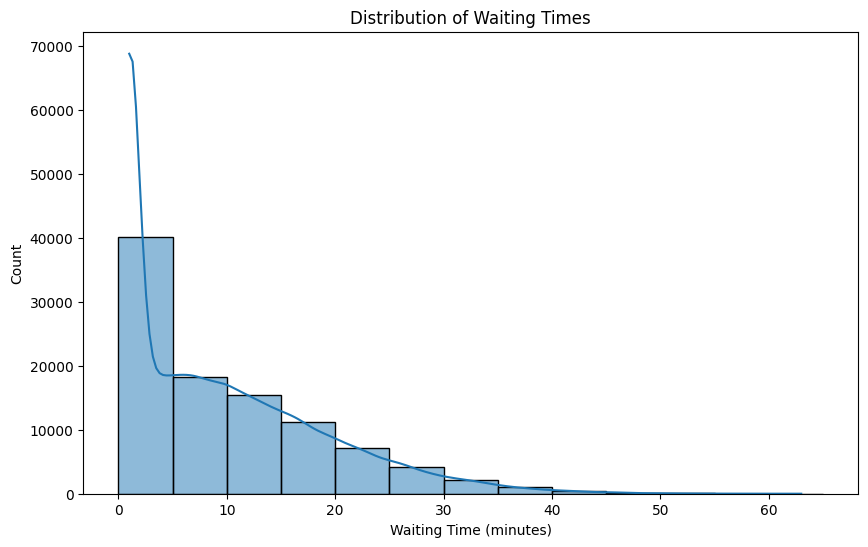

In [35]:
plt.figure(figsize=(10,6))
bins = range(0, int(df["wait_time"].max()) + 5, 5)

sns.histplot(df["wait_time"], bins=bins, kde=True)

plt.xlabel("Waiting Time (minutes)")
plt.ylabel("Count")
plt.title("Distribution of Waiting Times")
plt.xticks(range(0, int(df["wait_time"].max()) + 5, 10))
plt.show()

Histogrammet visar att väntetiderna är högerskev fördelade, där de flesta kunder har kort väntetid medan ett fåtal får betydligt längre. Detta tyder på att verksamheten oftast fungerar effektivt, men att det uppstår tillfällen med hög belastning som leder till längre väntetider.

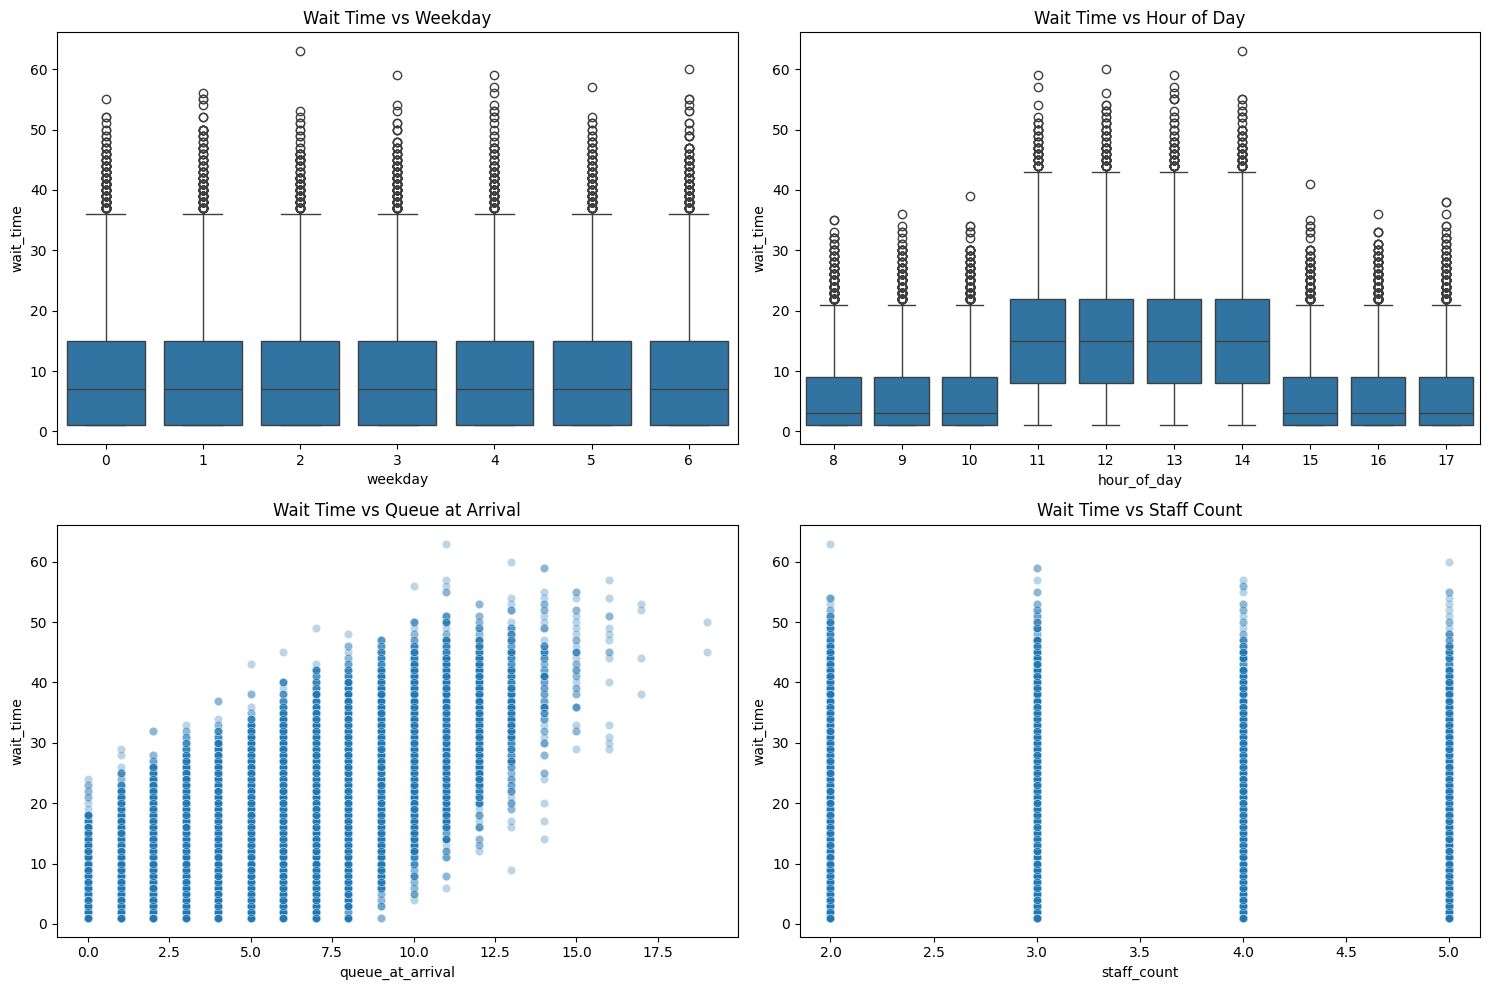

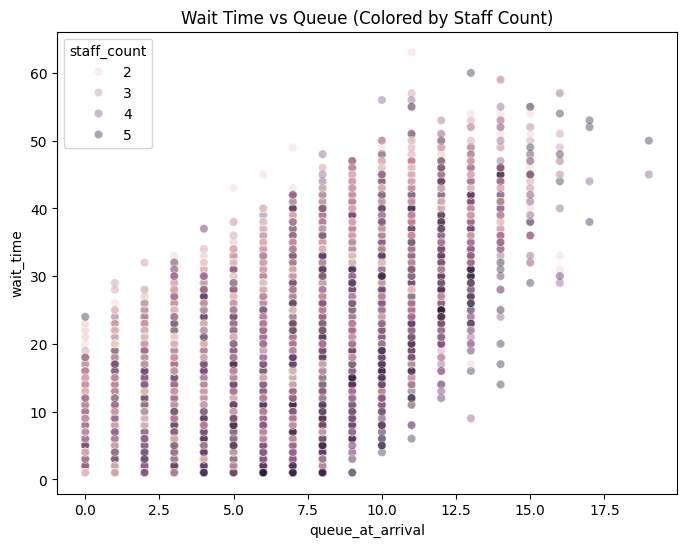

In [36]:
plt.figure(figsize=(15,10))

# 1: Weekday 
plt.subplot(2,2,1)
sns.boxplot(data=df, x="weekday", y="wait_time")
plt.title("Wait Time vs Weekday")

# 2: Hour 
plt.subplot(2,2,2)
sns.boxplot(data=df, x="hour_of_day", y="wait_time")
plt.title("Wait Time vs Hour of Day")

# 3: Queue 
plt.subplot(2,2,3)
sns.scatterplot(
    data=df, 
    x="queue_at_arrival", 
    y="wait_time",
    alpha=0.3
)
plt.title("Wait Time vs Queue at Arrival")

# 4: Staff
plt.subplot(2,2,4)
sns.scatterplot(
    data=df, 
    x="staff_count", 
    y="wait_time",
    alpha=0.3
)
plt.title("Wait Time vs Staff Count")

plt.tight_layout()
plt.show()


plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="queue_at_arrival",
    y="wait_time",
    hue="staff_count",
    alpha=0.4
)
plt.title("Wait Time vs Queue (Colored by Staff Count)")
plt.show()

<Axes: xlabel='hour_of_day', ylabel='wait_time'>

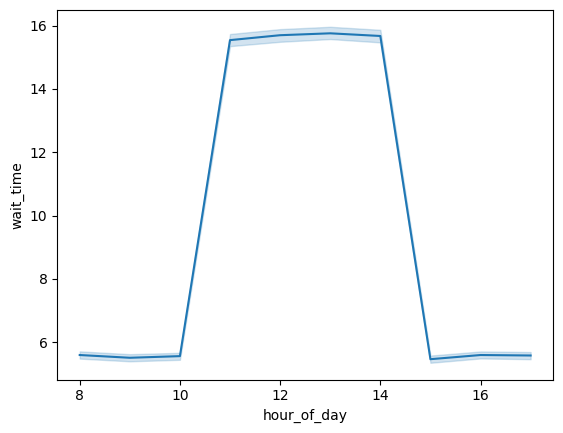

In [37]:
sns.lineplot(data=df, x="hour_of_day", y="wait_time")

Väntetiderna är låga och stabila mellan kl. 08–10, men ökar tydligt mellan kl. 11–15 där belastningen är som högst. Därefter sjunker väntetiderna igen under eftermiddagen.

In [38]:
num_cols = [
    "queue_at_arrival",
    "staff_count",
    "staff_experience_years",
    "staff_employment_percent",
    "age",
    "hour_of_day",

    "queue_per_staff",
    "is_weekend",
    "experience_load",
    "time_pressure",
    "experience_ratio",
    "busy_hour",
    "high_queue",

    "is_morning",
    "is_afternoon",
    "is_evening"
]

cat_cols = [
    "clinic_name",
    "location_type",
    "city",
    "season",
    "booking_type",
    "staff_employment_type",
    "visit_type",
    "vaccine_name",
    "vaccine_complexity"
]

In [39]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


Kolumnerna har delats upp i numeriska och kategoriska variabler för att möjliggöra korrekt preprocessing. Dubbletter och redundanta variabler har identifierats och tagits bort för att undvika överlappande information i modellen.

In [40]:
n_cols = X_train_processed.shape[1]

model_1 = Sequential()
model_1.add(Dense(64, activation='relu', input_shape=(n_cols,)))
model_1.add(Dense(32, activation='relu'))
model_1.add(Dense(1))

model_1.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_squared_error']
)

early_stopping_1 = EarlyStopping(patience=3)

model_1_trained=model_1.fit(
    X_train_processed,
    y_train,
    validation_split=0.2,
    epochs=50,
    callbacks=[early_stopping_1],
    verbose=True
)



c:\Users\sagal\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 24.3730 - mean_squared_error: 24.3730 - val_loss: 20.4219 - val_mean_squared_error: 20.4219
Epoch 2/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 20.7519 - mean_squared_error: 20.7519 - val_loss: 20.2846 - val_mean_squared_error: 20.2846
Epoch 3/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 20.6840 - mean_squared_error: 20.6840 - val_loss: 20.6914 - val_mean_squared_error: 20.6914
Epoch 4/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 20.6079 - mean_squared_error: 20.6079 - val_loss: 20.3135 - val_mean_squared_error: 20.3135
Epoch 5/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 20.5464 - mean_squared_error: 20.5464 - val_loss: 20.4914 - val_mean_squared_error: 20.4914


En enkel neuralt nätverksmodell skapades för att prediktera väntetid. Modellen består av två dolda lager med ReLU-aktivering och ett outputlager för regression.

Den tränades med Adam och mean squared error. Early stopping användes för att undvika överanpassning genom att avbryta träningen när modellen inte längre förbättras.

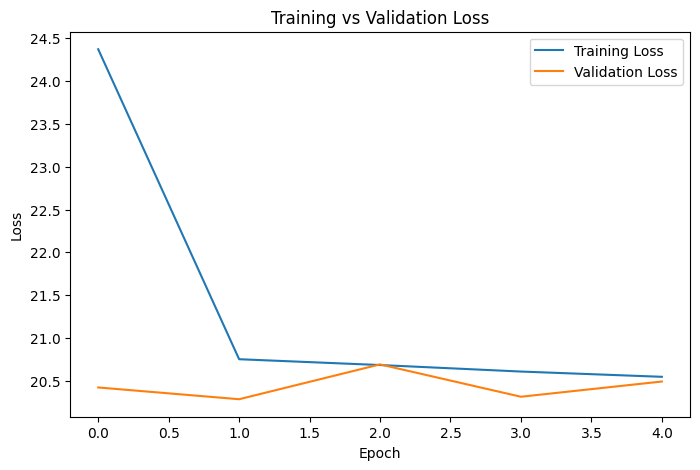

In [41]:
history = model_1_trained.history

train_loss = history['loss']
val_loss = history['val_loss']

plt.figure(figsize=(8,5))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Grafen visar att både training och validation loss minskar snabbt i början och stabiliseras efter några epoker. Validation loss förbättras fram till cirka epoch 2–3 och därefter sker ingen tydlig förbättring, vilket tyder på att modellen har nått sin optimala nivå.

In [42]:
n_cols = X_train_processed.shape[1] 
model_2 = Sequential() 
model_2.add(Dense(64, activation='relu', input_shape=(n_cols,)))
model_2.add(Dropout(0.2)) 
model_2.add(Dense(32, activation='relu')) 
model_2.add(Dense(1)) 

model_2.compile( 
    optimizer='adam', 
    loss='mse', 
    metrics=['mae'] ) 

early_stopping_2 = EarlyStopping( 
    monitor='val_loss', 
    patience=2, 
    restore_best_weights=True )


model_2_trained=model_2.fit( X_train_processed,
                             y_train, validation_split=0.2, 
                             epochs=50, batch_size=32, 
                             callbacks=[early_stopping_2], 
                             verbose=True )

Epoch 1/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 25.9693 - mae: 3.7074 - val_loss: 20.3824 - val_mae: 3.3541
Epoch 2/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 21.7079 - mae: 3.4657 - val_loss: 20.3696 - val_mae: 3.3988
Epoch 3/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 21.4914 - mae: 3.4481 - val_loss: 20.3664 - val_mae: 3.3942
Epoch 4/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 21.3402 - mae: 3.4429 - val_loss: 20.9932 - val_mae: 3.3997
Epoch 5/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 21.3111 - mae: 3.4396 - val_loss: 20.6451 - val_mae: 3.4368


Modellen visar snabb inlärning och når sin bästa prestanda runt epoch 3. Därefter börjar validation loss öka, vilket indikerar begynnande överanpassning. Early stopping säkerställer att modellen avbryts vid rätt tidpunkt och återgår till den bästa versionen.

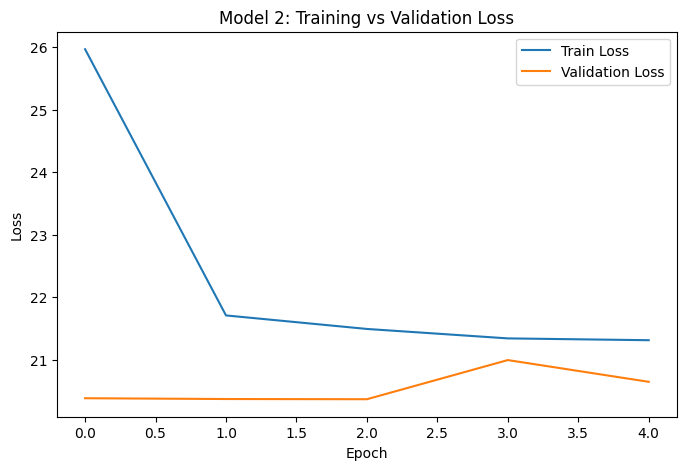

In [43]:
history_2 = model_2_trained.history

plt.figure(figsize=(8,5))
plt.plot(history_2['loss'], label='Train Loss')
plt.plot(history_2['val_loss'], label='Validation Loss')

plt.title('Model 2: Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

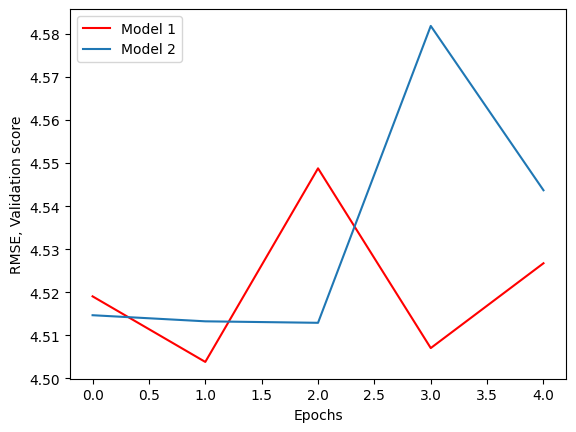

In [44]:
plt.plot(np.sqrt(model_1_trained.history['val_loss']), 'r', label='Model 1')
plt.plot(np.sqrt(model_2_trained.history['val_loss']), label='Model 2')
plt.xlabel('Epochs')
plt.ylabel('RMSE, Validation score')
plt.legend()

In [45]:
# Modell 2 når lägst RMSE runt epoch 2, vilket innebär att den presterar bäst vid tidig träning. 
# Därefter försämras resultatet, vilket tyder på överanpassning. 
# Modell 1 förbättras mer gradvis och är stabilare över flera epoker, men når inte lika låg RMSE som modell 2.

In [46]:
# Model 1
y_pred_1 = model_1.predict(X_test_processed)
rmse_1 = np.sqrt(mean_squared_error(y_test, y_pred_1))

# Model 2
y_pred_2 = model_2.predict(X_test_processed)
rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred_2))

print("Model 1 RMSE:", rmse_1)
print("Model 2 RMSE:", rmse_2)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 988us/step
Model 1 RMSE: 4.638102555523299
Model 2 RMSE: 4.613794309557829


In [47]:
# Lägg till predictions i din dataframe
df_results = X_test.copy()
df_results["actual_wait_time"] = y_test
df_results["predicted_wait_time"] = y_pred_2  # använd bästa modellen

# Spara som CSV
df_results.to_csv("wait_time_predictions.csv", index=False)

Resultatet visar att båda modellerna presterar liknande, med en RMSE på cirka 4.6 minuter. Modell 2 uppvisar en marginellt bättre prestanda, vilket indikerar att den mer komplexa arkitekturen bidrar till en viss förbättring. Skillnaden är dock liten, vilket tyder på att ytterligare modellkomplexitet endast ger begränsad effekt på prediktionsförmågan.




 Tillämpning i verkligheten 
 Modellen kan användas för att prediktera väntetider på kliniker baserat på faktorer
 som kölängd, personal och tid på dagen. Detta kan hjälpa verksamheten att planera
 resurser bättre, minska väntetider och förbättra patientupplevelsen.


 Möjligheter 
 - Optimera bemanning under hög belastning (t.ex. mitt på dagen)
 - Identifiera flaskhalsar i verksamheten
 - Förbättra planering och schemaläggning
 - Stödja beslutsfattande med datadrivna insikter

Utmaningar 
 - Modellens noggrannhet är begränsad (~4.6 min fel)
 - Resultaten beror starkt på datakvalitet och representativ data
 - Risk för att modellen inte generaliserar till nya eller förändrade situationer
 

 Etiska perspektiv 
- Viktigt att modellen inte leder till orättvis resursfördelning mellan patienter
- Beslut bör inte enbart baseras på modellen utan även på medicinsk bedömning
- Hantering av data måste följa integritets- och dataskyddsregler (t.ex. GDPR)